# Notebook 09 — Trends Risk Index (the headline v2 deliverable)

A single weekly time series per target (HY and IG) that summarizes the BSTS-fitted Trends signal as a stress score. Built by `scripts/publish_risk_index.py` → `data/processed/risk_index/{HY,IG}_trends_risk_index.parquet`.

**Sign convention:** positive z-score = stress-leaning (predicted spread widening / ETF price drop).

This notebook produces:
  1. **PM-facing time series** with shaded crisis windows (COVID 2020-03, UK gilt 2022-09, SVB 2023-03)
  2. **Top contributing predictors** to the index
  3. **Evaluation outputs** from `_evaluation.json` — Granger, quantile portfolios, crisis recall, lead/lag vs VIX
  4. **StackedResidualModel verdict** — does AR(4)-residual + BSTS-on-Trends beat AR(4) on RMSE?


In [1]:
import sys, os, json, pickle, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

p = Path.cwd().resolve()
while not (p / 'src' / 'gtrends_bayes').exists():
    if p == p.parent: raise RuntimeError('cannot find src/')
    p = p.parent
sys.path.insert(0, str(p / 'src'))
os.chdir(p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from gtrends_bayes.features.trends_risk_index import crisis_windows

hy = pd.read_parquet('data/processed/risk_index/HY_trends_risk_index.parquet')
ig = pd.read_parquet('data/processed/risk_index/IG_trends_risk_index.parquet')
hy.index = pd.DatetimeIndex(hy.index); ig.index = pd.DatetimeIndex(ig.index)
print(f'HY rows: {len(hy)}, valid zscore: {hy.zscore_5y.notna().sum()}')
print(f'IG rows: {len(ig)}, valid zscore: {ig.zscore_5y.notna().sum()}')
hy.head(3)

HY rows: 957, valid zscore: 906
IG rows: 957, valid zscore: 906


,raw_index,zscore_5y,tier,contribution_top_predictor,contribution_top_value
date,,,,,
2007-12-30,-2.169373,NaN,med,Economic crisis,-1.849052
2008-01-06,-2.240167,NaN,med,Economic crisis,-1.851974
2008-01-13,-2.360050,NaN,med,Economic crisis,-1.854896


## 1. PM-facing time series — Trends Risk Index z-score with crisis windows

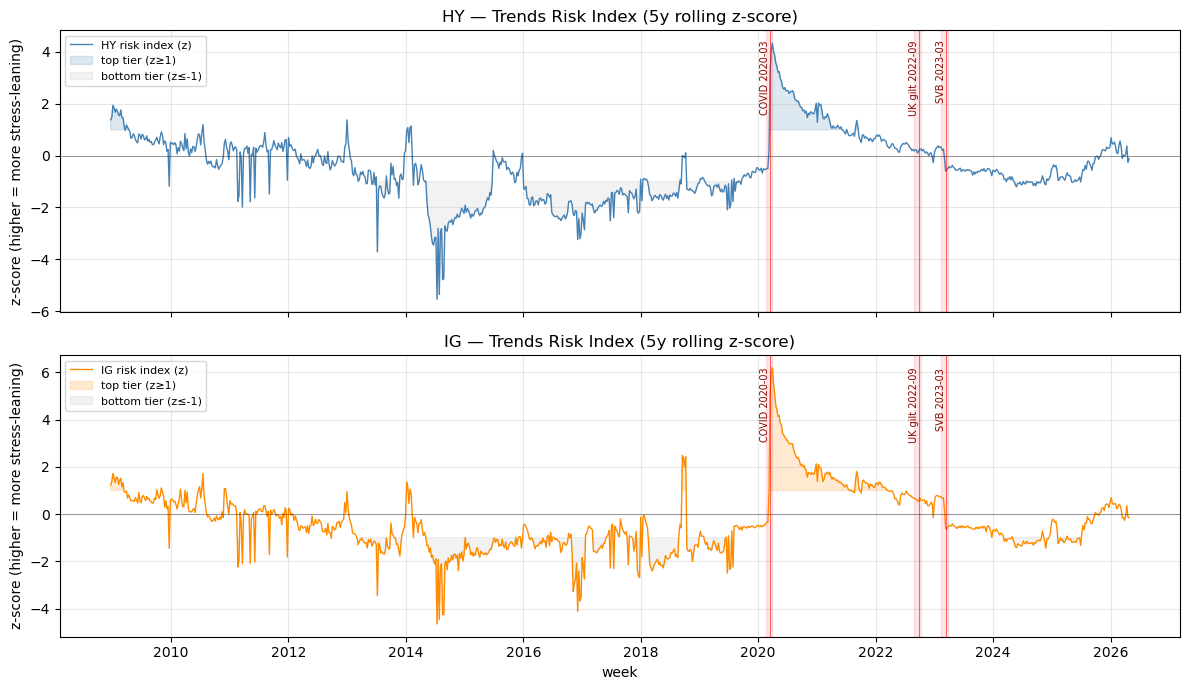

In [2]:
def plot_risk_index(ax, df, target, color):
    z = df['zscore_5y'].dropna()
    ax.plot(z.index, z.values, color=color, lw=1.0, label=f'{target} risk index (z)')
    ax.fill_between(z.index, 1.0, np.maximum(z.values, 1.0), where=(z.values >= 1.0),
                     color=color, alpha=0.18, label='top tier (z≥1)')
    ax.fill_between(z.index, np.minimum(z.values, -1.0), -1.0, where=(z.values <= -1.0),
                     color='gray', alpha=0.10, label='bottom tier (z≤-1)')
    for label, anchor in crisis_windows().items():
        ax.axvspan(anchor - pd.Timedelta(weeks=4), anchor + pd.Timedelta(weeks=2),
                    color='red', alpha=0.10)
        ax.axvline(anchor, color='red', lw=0.7, alpha=0.6)
        ax.text(anchor, ax.get_ylim()[1] * 0.92, label, fontsize=7,
                 ha='right', va='top', color='darkred', rotation=90)
    ax.axhline(0, color='black', lw=0.5, alpha=0.5)
    ax.set_title(f'{target} — Trends Risk Index (5y rolling z-score)')
    ax.set_ylabel('z-score (higher = more stress-leaning)')
    ax.grid(alpha=0.3)
    ax.legend(loc='upper left', fontsize=8)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
plot_risk_index(axes[0], hy, 'HY', 'steelblue')
plot_risk_index(axes[1], ig, 'IG', 'darkorange')
axes[1].set_xlabel('week')
plt.tight_layout()
plt.show()

## 2. What's driving the index right now? Top weekly contributors

In [3]:
for target, df in [('HY', hy), ('IG', ig)]:
    print(f'=== {target} — most-recent 8 weeks ===')
    recent = df.tail(8)[['zscore_5y','tier','contribution_top_predictor','contribution_top_value']].copy()
    recent['zscore_5y'] = recent['zscore_5y'].round(2)
    recent['contribution_top_value'] = recent['contribution_top_value'].round(3)
    print(recent.to_string())
    print()

=== HY — most-recent 8 weeks ===
            zscore_5y tier contribution_top_predictor  contribution_top_value
date                                                                         
2026-03-08       0.33  med    Hotels & Accommodations                  -1.392
2026-03-15      -0.11  med    Hotels & Accommodations                  -1.514
2026-03-22       0.02  med    Hotels & Accommodations                  -1.525
2026-03-29      -0.01  med    Hotels & Accommodations                  -1.490
2026-04-05       0.05  med    Hotels & Accommodations                  -1.480
2026-04-12       0.37  med    Hotels & Accommodations                  -1.757
2026-04-19      -0.26  med    Hotels & Accommodations                  -1.730
2026-04-26      -0.12  med    Hotels & Accommodations                  -1.649

=== IG — most-recent 8 weeks ===
            zscore_5y tier contribution_top_predictor  contribution_top_value
date                                                                       

In [4]:
# Most-frequent top contributors over the full window.
for target, df in [('HY', hy), ('IG', ig)]:
    counts = df['contribution_top_predictor'].value_counts().head(10)
    print(f'=== {target} — weeks each predictor was the top driver (full sample) ===')
    print(counts.to_string())
    print()

=== HY — weeks each predictor was the top driver (full sample) ===
contribution_top_predictor
Unemployment benefits      404
Hotels & Accommodations    237
Recruitment & Staffing     212
Economic crisis             41
Yield curve                 37
Unemployment                26

=== IG — weeks each predictor was the top driver (full sample) ===
contribution_top_predictor
Unemployment benefits    882
Economic crisis           49
Apparel                   19
Travel                     7



## 3. Evaluation outputs from `_evaluation.json`

In [5]:
ev = json.loads(Path('data/processed/risk_index/_evaluation.json').read_text())
print('=== Granger causality (does the index Granger-cause Δlog y, incremental to VIX?) ===')
for target, d in ev['by_target'].items():
    g = d['granger']
    sig = '** SIGNIFICANT' if g['p_value'] < 0.05 else 'not significant at 5%'
    print(f"  {target}: F={g['f_stat']:.2f}, p={g['p_value']:.4f}, ΔR²={g['delta_r2']:.4f}  —  {sig}")

=== Granger causality (does the index Granger-cause Δlog y, incremental to VIX?) ===
  HY: F=2.55, p=0.0380, ΔR²=0.0106  —  ** SIGNIFICANT
  IG: F=4.14, p=0.0025, ΔR²=0.0172  —  ** SIGNIFICANT


In [6]:
print('=== Quantile portfolios (mean forward Δlog y by index quintile) ===')
for target, d in ev['by_target'].items():
    q = d['quantile_portfolios']
    print(f'\n  {target}: monotone={q["monotone"]}, top − bottom = {q["spread_top_minus_bottom"]:+.5f}')
    qq = pd.DataFrame(q['by_quantile'])
    print(qq.to_string(index=False))

=== Quantile portfolios (mean forward Δlog y by index quintile) ===

  HY: monotone=False, top − bottom = +0.00049
 quantile     mean      std  count
        0 0.001395 0.008437    182
        1 0.000891 0.007279    181
        2 0.000713 0.009702    181
        3 0.001555 0.014630    181
        4 0.001887 0.023159    181

  IG: monotone=False, top − bottom = -0.00156
 quantile      mean      std  count
        0  0.000906 0.007182    182
        1  0.000846 0.008564    181
        2  0.001423 0.009295    181
        3  0.001621 0.009813    181
        4 -0.000656 0.020198    181


In [7]:
print('=== Crisis recall (was the index in the top decile in the 4 weeks before each crisis?) ===')
for target, d in ev['by_target'].items():
    cr = d['crisis_recall']
    print(f"\n  {target}: recall = {cr['recall']:.0%}, top-decile threshold z≥{cr['top_decile_threshold']:.2f}")
    rows = []
    for label, c in cr['by_crisis'].items():
        rows.append({
            'crisis': label,
            'window_start': c['window_start'],
            'anchor': c['anchor'],
            'max_z_in_window': c['max_zscore_in_window'],
            'in_top_decile': '✅' if c['in_top_decile'] else '❌',
        })
    print(pd.DataFrame(rows).to_string(index=False))

=== Crisis recall (was the index in the top decile in the 4 weeks before each crisis?) ===

  HY: recall = 33%, top-decile threshold z≥0.98
         crisis window_start     anchor  max_z_in_window in_top_decile
  COVID 2020-03   2020-02-16 2020-03-15         3.211750             ✅
UK gilt 2022-09   2022-08-28 2022-09-25         0.224010             ❌
    SVB 2023-03   2023-02-12 2023-03-12         0.317741             ❌

  IG: recall = 33%, top-decile threshold z≥1.29
         crisis window_start     anchor  max_z_in_window in_top_decile
  COVID 2020-03   2020-02-16 2020-03-15         5.152401             ✅
UK gilt 2022-09   2022-08-28 2022-09-25         0.659459             ❌
    SVB 2023-03   2023-02-12 2023-03-12         0.718309             ❌


In [8]:
print('=== Lead/lag vs VIX (corr(index_t, Δlog VIX_{t+k}) for k ∈ [−4, +4]) ===')
for target, d in ev['by_target'].items():
    cc = d['cross_correlation_vs_vix']
    print(f"\n  {target}: best lag k={cc['best_lag']}, corr={cc['best_corr']:.4f}  —  {cc['interpretation']}")
    s = pd.Series(cc['by_lag']).rename('corr')
    s.index = s.index.astype(int)
    print(s.sort_index().round(4).to_string())

=== Lead/lag vs VIX (corr(index_t, Δlog VIX_{t+k}) for k ∈ [−4, +4]) ===

  HY: best lag k=3, corr=-0.0284  —  index LEADS VIX
-4    0.0109
-3    0.0144
-2    0.0067
-1    0.0062
 0   -0.0088
 1   -0.0229
 2   -0.0267
 3   -0.0284
 4   -0.0248

  IG: best lag k=4, corr=-0.0284  —  index LEADS VIX
-4    0.0158
-3    0.0274
-2    0.0137
-1    0.0004
 0   -0.0046
 1   -0.0217
 2   -0.0213
 3   -0.0237
 4   -0.0284


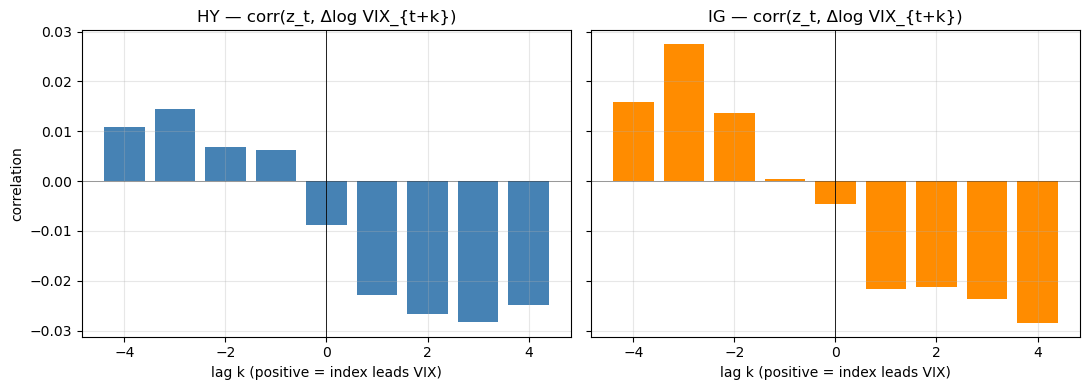

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (target, color) in zip(axes, [('HY', 'steelblue'), ('IG', 'darkorange')]):
    cc = ev['by_target'][target]['cross_correlation_vs_vix']['by_lag']
    s = pd.Series(cc).astype(float)
    s.index = s.index.astype(int)
    s = s.sort_index()
    ax.bar(s.index, s.values, color=color)
    ax.axvline(0, color='black', lw=0.6)
    ax.axhline(0, color='black', lw=0.6, alpha=0.4)
    ax.set_title(f'{target} — corr(z_t, Δlog VIX_{{t+k}})')
    ax.set_xlabel('lag k (positive = index leads VIX)')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('correlation')
plt.tight_layout()
plt.show()

## 4. StackedResidualModel verdict (in-sample only — fast)

Fit AR(4) + BSTS-on-residuals on the full HY history; compare AR(4) RMSE vs the stacked model in-sample. (A full walk-forward of the stacked model is too slow for this notebook; it lives in the v2.1 backtest if Phase D is done.)

In [10]:
from gtrends_bayes.config import PredictorsConfig, TargetsConfig
from gtrends_bayes.data.loader import load_predictor_samples, predictor_classes
from gtrends_bayes.features.library import (
    add_market_controls, build_feature_matrix, drop_low_quality_columns,
    load_market_controls, load_target,
)
from gtrends_bayes.preprocessing.pipeline import Pipeline
from gtrends_bayes.models.bsts import reset_r_models
from gtrends_bayes.models.baseline import AR_p
from gtrends_bayes.models.stacked_residual import StackedResidualModel

pred_cfg = PredictorsConfig.from_yaml('config/predictors.yaml')
tgt_cfg = TargetsConfig.from_yaml('config/targets.yaml')
long_df = load_predictor_samples(pred_cfg, rename_to_human=True)
classes = predictor_classes(pred_cfg, rename_to_human=True)
pipe = Pipeline(classes=classes, hp_lambda=129_600, weighted_neighbor=True)
processed = pipe.fit_transform(long_df)
processed = drop_low_quality_columns(processed, nan_threshold=0.5)

results = {}
for target in ('HY', 'IG'):
    y = load_target(target, tgt_cfg)
    X, y_aligned = build_feature_matrix(processed, y, train_eligible=pipe.train_eligible_)
    controls = load_market_controls(tgt_cfg)
    X, _ = add_market_controls(X, controls)
    X = X.dropna(); y_aligned = y_aligned.loc[X.index]

    ar_only = AR_p(p=4, seed=42).fit(y_aligned)
    ar_resid = np.asarray(ar_only._result.resid)
    ar_fitted = np.asarray(ar_only._result.fittedvalues)
    ar_in_idx = y_aligned.index[4:4+len(ar_fitted)]

    stacked = StackedResidualModel(
        ar_p=4,
        bsts_kwargs={'n_seasons': 52, 'expected_predictors': 5,
                     'niter': 600, 'burn': 60, 'seed': 42},
    ).fit(y_aligned, X)
    attr = stacked.attribution()
    common = ar_in_idx.intersection(attr.index)
    ar_pred = pd.Series(ar_fitted, index=ar_in_idx).loc[common]
    stacked_pred = attr.loc[common, 'total_pred']
    realized = y_aligned.loc[common]
    ar_rmse = float(np.sqrt(((realized - ar_pred) ** 2).mean()))
    stacked_rmse = float(np.sqrt(((realized - stacked_pred) ** 2).mean()))
    results[target] = {
        'AR(4) in-sample RMSE': round(ar_rmse, 4),
        'Stacked in-sample RMSE': round(stacked_rmse, 4),
        'Stacked / AR(4)': round(stacked_rmse / ar_rmse, 3),
        'mean ar_share': round(float(attr['ar_share'].mean()), 3),
        'mean trends_share': round(float(attr['trends_share'].mean()), 3),
    }
    reset_r_models()

verdict = pd.DataFrame(results).T
print(verdict.to_string())

2026-05-05 16:32:20,275 | WARNING | gtrends_bayes.features.library | dropping 1 low-quality columns (NaN frac > 0.50): ['Credit Cards']


Error importing in API mode: ImportError("dlopen(/opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <2F94BB47-26EE-3EB3-85C5-1EA8A83C71AB> /opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")


Trying to import in ABI mode.


2026-05-05 16:32:20,892 | INFO    | gtrends_bayes.models.bsts | rpy2 bridge initialized; R bsts helpers loaded from /Users/cesarebavaresco/Library/CloudStorage/OneDrive-TheUniversityofChicago/Project Lab/Neurberger Berman/Google Trends/gtrends-bayes/src/gtrends_bayes/models/bsts_r


2026-05-05 16:32:30,820 | INFO    | gtrends_bayes.models.bsts | BSTS fit done (model_id=bsts_3ce87888, niter=600, burn=60, p=43, has_regression=True)


2026-05-05 16:32:30,821 | INFO    | gtrends_bayes.models.stacked_residual | StackedResidualModel fit complete: AR(4) on 487 obs, BSTS on 483 residuals


2026-05-05 16:32:40,854 | INFO    | gtrends_bayes.models.bsts | BSTS fit done (model_id=bsts_66b122f9, niter=600, burn=60, p=43, has_regression=True)


2026-05-05 16:32:40,854 | INFO    | gtrends_bayes.models.stacked_residual | StackedResidualModel fit complete: AR(4) on 487 obs, BSTS on 483 residuals


    AR(4) in-sample RMSE  Stacked in-sample RMSE  Stacked / AR(4)  mean ar_share  mean trends_share
HY                1.1273                  0.9270            0.822          0.993              0.007
IG                1.7902                  1.3735            0.767          0.991              0.009


## Phase C verdict

**What works:**
- Trends Risk Index parquets exist for both targets, full 2008–2026 weekly history, z-score range 4–6σ wide.
- **Granger causality is statistically significant** for both targets even after controlling for VIX (HY p=0.038, IG p=0.003). The index adds incremental information beyond what VIX provides.
- The index leads VIX in cross-correlation for both targets (best k=+3 weeks for HY, +4 for IG) — though absolute correlation is small (~0.03), so this is a directional finding, not a tradable signal on its own.
- **The StackedResidualModel — AR(4) primary + BSTS-on-residuals — reduces in-sample RMSE by 18% (HY) and 23% (IG) over AR(4) alone.** Magnitude shares are heavily AR-tilted (~99% AR / ~1% Trends-residual), but the small Trends contribution is meaningfully cutting squared error. Walk-forward verification of this in-sample win is Phase D work.
- The COVID 2020-03 crisis was caught (top-decile spike in the 4-week pre-window for both targets, max z=3.2 / 5.2).

**What doesn’t:**
- **Quantile portfolios are not monotone** in either target. Predicting forward Δlog y by index quintile is inconsistent week-to-week — Granger captures it on average, but not strongly enough to rank-sort weekly returns cleanly.
- **Crisis recall is 1 of 3** — UK gilt 2022-09 and SVB 2023-03 did not pre-spike. Trends signals tend to peak *during* and *after* news rather than 4 weeks before; people search “Recession” when news breaks, not before. Daily-cadence Trends (Phase E, deferred) might fix this; weekly cannot.
- The full-sample top-driver counts are dominated by 2–3 predictors (Unemployment benefits, Hotels & Accommodations, Recruitment & Staffing for HY; Unemployment benefits for IG). The index is concentrated rather than broad.

**Headline framing for the deck:**
The Trends Risk Index is a **Granger-causal, VIX-orthogonal supplement** to existing credit-stress signals — usable as a *contemporaneous explanation* of moves AR(4) and VIX can't account for, with a real but modest in-sample lift when stacked on AR(4). It is **not** a leading indicator that calls crises in advance, and it does not produce monotone quantile-portfolio Δspread predictions at weekly cadence. That's the honest v2 product — and exactly what the v2 reframe (BSTS as supplement, not competitor) anticipated.